---
title: "Clenshaw algorithm"
description: "チェビシェフ多項式を例に Clenshaw algorithm の適用方法を説明し，Python による実装および検証を示す"
date: 2026-07-15T09:00:00+09:00
categories:
  - computerscience
  - numericalanalysis
draft: false
format:
  html:
    code-fold: true
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hasenpfote/hasenpfote.github.io/blob/main/posts/clenshaw-algorithm.ipynb)[]()


## はじめに

一般に，Clenshaw algorithm は，三項漸化式を満たす関数列 $\{\phi_{k}(x)\}$ の有限級数

$$
S(x) =\sum_{k=0}^{n}a_{k}\phi_{k}(x)  
$$

を効率よく評価するアルゴリズムである．ここでは，代表的な例としてチェビシェフ多項式を用い，アルゴリズムの適用方法を示す．

## 三項漸化式

関数列 $\{\phi_{k}\},\,k=0,1,\dots$ が，適切な初期条件の下で三項漸化式

$$
\phi_{k+1}(x) =\alpha_{k}(x)\phi_{k}(x)+\beta_{k}(x)\phi_{k-1}(x) ,\qquad(k\ge 1)  
$$

を満たすとする．評価対象を

$$
S(x) =\sum_{k=0}^{n}a_{k}\phi_{k}(x)  
$$

とする．

## チェビシェフ多項式

チェビシェフ多項式は，

$$
T_{n}(\cos{\theta}) =\cos{(n\theta)}  
$$

で定義される．初期条件は，

$$
T_{0}(x)=1 ,\quad T_{1}(x)=x  
$$

であり，三項漸化式

$$
T_{n+1}(x) =2xT_{n}(x)-T_{n-1}(x)  
$$

を満たす．したがって，一般形

$$
\phi_{k+1}(x) =\alpha_{k}(x)\phi_{k}(x)+\beta_{k}(x)\phi_{k-1}(x)  
$$

と比較すると，

$$
\alpha_{k}(x)=2x ,\quad \beta_{k}=-1  
$$

となる．

## Clenshaw algorithm

Clenshaw algorithm は，次の逆向き漸化式を用いて評価を行う．

$$
\begin{align*} b_{n+1}(x)&=b_{n+2}(x)=0,\\ b_{k}(x)&=a_{k}+\alpha_{k}(x)b_{k+1}(x)+\beta_{k+1}(x)b_{k+2}(x) \end{align*}  
$$

このとき，評価対象 $S(x)$ は

$$
S(x) =\phi_{0}(x)a_{0}+\phi_{1}(x)b_{1}(x)+\beta_{1}(x)\phi_{0}(x)b_{2}(x)  
$$

と表される．チェビシェフ多項式では，

$$
\phi_{0}(x)=1 ,\quad \phi_{1}(x)=x ,\quad \alpha_{k}(x)=2x ,\quad \beta_{k}(x)=-1  
$$

である．このとき，逆向き漸化式は

$$
b_{k}(x)=a_{k}+2xb_{k+1}(x)-b_{k+2}(x)  
$$

となり，評価式は

$$
S(x) =a_{0}+xb_{1}(x)-b_{2}(x)  
$$

となる．

## 計算例

4 次のチェビシェフ級数

$$
S(x) =a_{0}+a_{1}T_{1}(x)+a_{2}T_{2}(x)+a_{3}T_{3}(x)+a_{4}T_{4}(x)  
$$

に対して，Clenshaw algorithm を適用する．初期条件

$$
b_{5}(x)=b_{6}(x)=0  
$$

および逆向き漸化式

$$
b_{k}(x)=a_{k}+2xb_{k+1}(x)-b_{k+2}(x)  
$$

を用いると，

$$
\begin{array}{l|l} k & b_k(x)\\ \hline 4 & \begin{aligned} b_{4}(x) &=a_{4} \end{aligned}\\ \hline 3 & \begin{aligned} b_{3}(x) &=a_{3}+2xa_{4} \end{aligned}\\ \hline 2 & \begin{aligned} b_{2}(x) &=a_{2}+2xb_{3}(x)-b_{4}(x)\\ &=a_{2}+2xa_{3}+(4x^{2}-1)a_{4} \end{aligned}\\ \hline 1 & \begin{aligned} b_{1}(x) &=a_{1}+2xb_{2}(x)-b_{3}(x)\\ &=a_{1}+2xa_{2}+(4x^{2}-1)a_{3}+(8x^{3}-4x)a_{4} \end{aligned}\\ \hline 0 & \begin{aligned} b_{0}(x) &=a_{0}+2xb_{1}(x)-b_{2}(x)\\ &=a_{0}+2xa_{1}+(4x^{2}-1)a_{2}\\ &\quad +(8x^{3}-4x)a_{3}+(16x^{4}-12x^{2}+1)a_{4} \end{aligned}\\ \end{array}  
$$

## 確認

評価式

$$
S(x) =a_{0}+xb_{1}(x)-b_{2}(x)  
$$

に，計算例で求めた $b_{1}(x)$ および $b_{2}(x)$ を代入すると，

$$
\begin{align*} S(x) &=a_{0}+x\left(a_{1}+2xa_{2}+(4x^{2}-1)a_{3}+(8x^{3}-4x)a_{4}\right)-\left(a_{2}+2xa_{3}+(4x^{2}-1)a_{4}\right)\\ &=a_{0}+xa_{1}+(2x^{2}-1)a_{2}+(4x^{3}-3x)a_{3}+(8x^{4}-8x^{2}+1)a_{4}\\ &=a_{0}+a_{1}T_{1}(x)+a_{2}T_{2}(x)+a_{3}T_{3}(x)+a_{4}T_{4}(x) \end{align*}  
$$

したがって，Clenshaw algorithm により，チェビシェフ級数が正しく評価されることが確認できる．

## 検証

ここでは，Python を用いて近似精度および実装の正しさを検証する．

### atan の検証

Numpy の atan を基準として，Taylor および Chebyshev 近似の精度を比較する．また，自前で実装した Clenshaw algorithm の評価結果が `chebval` と一致することを確認する．

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
from numpy.polynomial.chebyshev import chebfit, chebval


def clenshaw(x, coef):
    n = len(coef) - 1
    b1 = b2 = 0.0

    for k in range(n, 0, -1):
        b0 = coef[k] + 2.0 * x * b1 - b2
        b2 = b1
        b1 = b0

    return coef[0] + x * b1 - b2


def map_to_chebyshev_domain(x, a, b):
    return (2.0 * x - (a + b)) / (b - a)


def max_abs_error(ref, approx):
    return np.max(np.abs(ref - approx))


def make_taylor(var, f_expr, degree, x0=0.0):
    p_expr = f_expr.series(x=var, x0=x0, n=degree + 1).removeO()
    f_taylor = sp.lambdify(var, p_expr, "numpy")
    return p_expr, f_taylor


def fit_chebyshev(f, a, b, degree, num_fit_points=1000):
    xs = np.linspace(a, b, num_fit_points)
    t = map_to_chebyshev_domain(xs, a, b)
    return chebfit(t, f(xs), degree)


def approximate(
    var,
    f_expr,
    a=0.0,
    b=1.0,
    degree=4,
    x0=0.0,
    num_fit_points=1000,
    num_eval_points=1000,
):
    # evaluation points
    x = np.linspace(a, b, num_eval_points)

    f = sp.lambdify(var, f_expr, "numpy")
    y_ref = f(x)

    # Taylor
    p_expr, f_taylor = make_taylor(var, f_expr, degree, x0)
    y_taylor = f_taylor(x)

    # Chebyshev
    coef = fit_chebyshev(f, a, b, degree, num_fit_points)
    t = map_to_chebyshev_domain(x, a, b)
    y_cheb = chebval(t, coef)
    y_clenshaw = np.fromiter((clenshaw(ti, coef) for ti in t), dtype=np.float64)

    return {
        "a": a,
        "b": b,
        "degree": degree,
        "num_fit_points": num_fit_points,
        "num_eval_points": num_eval_points,
        "x": x,
        "p_expr": p_expr,
        "coef": coef,
        "y_ref": y_ref,
        "y_taylor": y_taylor,
        "y_cheb": y_cheb,
        "y_clenshaw": y_clenshaw,
    }


def evaluate_error(result):
    y_ref = result["y_ref"]

    result["err_taylor"] = max_abs_error(y_ref, result["y_taylor"])
    result["err_cheb"] = max_abs_error(y_ref, result["y_cheb"])
    result["err_clenshaw"] = max_abs_error(y_ref, result["y_clenshaw"])
    result["err_impl"] = max_abs_error(result["y_cheb"], result["y_clenshaw"])

    return result


def print_result(result):
    print(f"Interval     : [{result['a']}, {result['b']}]")
    print(f"Degree       : {result['degree']}")
    print(f"Fit samples  : {result['num_fit_points']}")
    print(f"Eval samples : {result['num_eval_points']}")
    print()
    print(f"Taylor approximation error    : {result['err_taylor']}")
    print(f"Chebyshev approximation error : {result['err_cheb']}")
    print(f"Clenshaw approximation error  : {result['err_clenshaw']}")
    print(f"chebval vs Clenshaw           : {result['err_impl']}")
    print(f"Taylor / Clenshaw error ratio : {result['err_taylor'] / result['err_clenshaw']}")
    print("\nChebyshev coefficients :")
    print(result["coef"])


def plot_result(result):
    a = result["a"]
    b = result["b"]
    x = result["x"]
    y_ref = result["y_ref"]

    fig, ax = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

    ax[0].plot(x, y_ref, label="f(x)")

    methods = [
        (result["y_taylor"], "-", "Taylor"),
        (result["y_cheb"], "--", "chebval"),
        (result["y_clenshaw"], ":", "Clenshaw"),
    ]

    for y, ls, label in methods:
        # Approximation
        (line,) = ax[0].plot(x, y, linestyle=ls, label=label)
        # Absolute error
        ax[1].semilogy(x, np.abs(y_ref - y), color=line.get_color(), linestyle=ls, label=label)

    ax[0].set_ylabel("y")
    ax[0].set_title(f"Approximation on [{a:.3f}, {b:.3f}]")
    ax[0].grid(True)
    ax[0].legend()

    ax[1].set_xlabel("x")
    ax[1].set_ylabel("Absolute Error")
    ax[1].set_title("Approximation Error (log scale)")
    ax[1].grid(True, which="both")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


def degree_error(degrees, **approximate_kwargs):
    for degree in degrees:
        res = approximate(degree=degree, **approximate_kwargs)
        res = evaluate_error(res)

        yield (degree, res["err_taylor"], res["err_cheb"])


def plot_degree_error(ax, degrees, **approximate_kwargs):
    degrees_ = []
    errors_taylor = []
    errors_cheb = []

    for degree, err_taylor, err_cheb in degree_error(degrees, **approximate_kwargs):
        degrees_.append(degree)
        errors_taylor.append(err_taylor)
        errors_cheb.append(err_cheb)

    ax.semilogy(degrees_, errors_taylor, marker="o", label="Taylor")
    ax.semilogy(degrees_, errors_cheb, marker="o", label="Chebyshev")
    ax.set_xlabel("Degree")
    ax.set_ylabel("Maximum Absolute Error")
    ax.set_title("Maximum Approximation Error vs Degree")
    ax.set_xticks(degrees_)
    ax.grid(True, which="both")
    ax.legend()

    plt.tight_layout()
    plt.show()

$f(x)=\operatorname{atan}{\left(x \right)}$

$T_{5}(x)=\frac{x^{5}}{5} - \frac{x^{3}}{3} + x$


Interval     : [0.0, 1.0]
Degree       : 5
Fit samples  : 1000
Eval samples : 1000

Taylor approximation error    : 0.08126850326921842
Chebyshev approximation error : 5.643978144759254e-05
Clenshaw approximation error  : 5.643978144752662e-05
chebval vs Clenshaw           : 1.1102230246251565e-16
Taylor / Clenshaw error ratio : 1439.915272258374

Chebyshev coefficients :
[ 4.27082567e-01  3.94734004e-01 -3.54469480e-02 -1.94361069e-03
  1.10527353e-03 -1.05941526e-04]


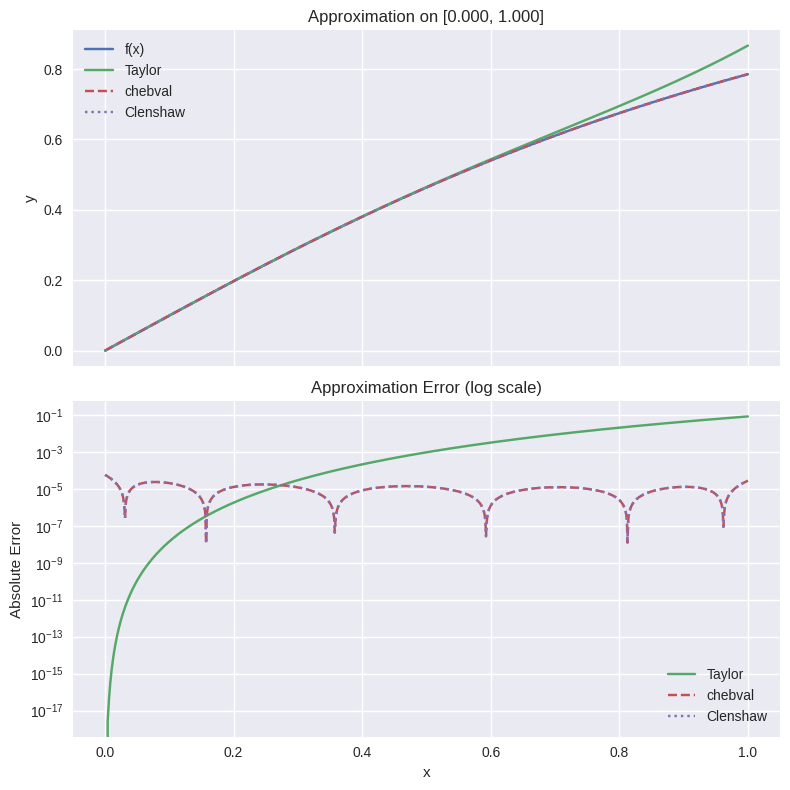

In [2]:
from IPython.display import Markdown, display

# print(plt.style.available)
plt.style.use("seaborn-v0_8")

x = sp.symbols("x")
f_expr = sp.atan(x)

approximate_kwargs = {
    "var": x,
    "f_expr": f_expr,
    "a": 0.0,
    "b": 1.0,
}

res = approximate(degree=5, **approximate_kwargs)
degree = sp.Poly(res["p_expr"], x).degree()
display(Markdown(f"$f(x)={sp.latex(f_expr)}$"))
display(Markdown(f"$T_{{{degree}}}(x)={sp.latex(res['p_expr'])}$"))

res = evaluate_error(res)

print()
print_result(res)
plot_result(res)

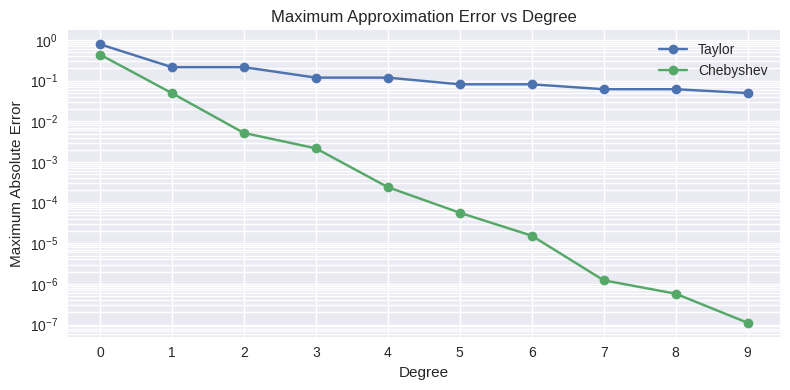

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
plot_degree_error(ax, degrees=range(0, 10), **approximate_kwargs)

### atan2 の検証

近似した atan を用いて atan2 を実装する．まず，Desmos を用いて変数変換および象限補正を確認する．

<div class="quarto-figure quarto-figure-center">
<figure class="figure">
<iframe src="https://www.desmos.com/calculator/jur27fjpyp?embed"></iframe>
<figcaption>象限補正を確認する</figcaption>
</figure>
</div>

以下に，実装例を示す．

In [4]:
def atan_approx(x):
    t = map_to_chebyshev_domain(x, res["a"], res["b"])
    return clenshaw(t, res["coef"])
    # return np.arctan(x)


def atan2_approx(y, x):
    y = np.asarray(y)
    x = np.asarray(x)

    ax = np.abs(x)
    ay = np.abs(y)

    # atan approximation on [0, 1]
    denom = np.maximum(ax, ay)
    s = np.divide(np.minimum(ax, ay), denom, out=np.zeros_like(denom), where=denom != 0.0)
    a = atan_approx(s)

    # |y| > |x|
    a = np.where(ay > ax, 0.5 * np.pi - a, a)

    # x < 0 side
    a = np.where(np.signbit(x), np.pi - a, a)

    # y < 0 side
    a = np.where(np.signbit(y), -a, a)

    # Handle signed-zero cases
    zero = (ax == 0.0) & (ay == 0.0)
    a = np.where(zero & np.signbit(x) & np.signbit(y), -np.pi, a)  # (-0, -0)
    a = np.where(zero & np.signbit(x) & ~np.signbit(y), np.pi, a)  # (-0, +0)
    a = np.where(zero & ~np.signbit(x), np.copysign(0.0, y), a)  # (+0, +/-0)

    return a

In [5]:
def test_zero_cases():
    print("=== zero cases ===")
    tests = np.array(
        [
            [+0.0, +0.0],
            [+0.0, -0.0],
            [-0.0, -0.0],
            [-0.0, +0.0],
        ]
    )

    y = tests[:, 0]
    x = tests[:, 1]

    ref = np.atan2(y, x)
    approx = atan2_approx(y, x)

    for yi, xi, r, a in zip(y, x, ref, approx):
        print(f"atan2({yi:+}, {xi:+}) ref={r:+.16f}, approx={a:+.16f}, equal={r == a}")


def test_axis_cases():
    print("=== axis cases ===")
    tests = np.array(
        [
            [+1.0, +0.0],
            [-1.0, +0.0],
            [+1.0, -0.0],
            [-1.0, -0.0],
            [+0.0, +1.0],
            [+0.0, -1.0],
            [-0.0, +1.0],
            [-0.0, -1.0],
        ]
    )

    y = tests[:, 0]
    x = tests[:, 1]

    ref = np.atan2(y, x)
    approx = atan2_approx(y, x)

    for yi, xi, r, a in zip(y, x, ref, approx):
        print(f"atan2({yi:+}, {xi:+}) ref={r:+.16f}, approx={a:+.16f}, error={abs(r - a):.3e}")


def test_diagonal_cases():
    print("=== diagonal cases ===")
    tests = np.array(
        [
            [+1.0, +1.0],
            [+1.0, -1.0],
            [-1.0, -1.0],
            [-1.0, +1.0],
        ]
    )

    y = tests[:, 0]
    x = tests[:, 1]

    ref = np.atan2(y, x)
    approx = atan2_approx(y, x)

    for yi, xi, r, a in zip(y, x, ref, approx):
        print(f"atan2({yi:+}, {xi:+}) ref={r:+.16f}, approx={a:+.16f}, error={abs(r - a):.3e}")


def test_random_cases():
    print("=== random cases ===")
    rng = np.random.default_rng(0)
    y = rng.uniform(-1.0, 1.0, 1000000)
    x = rng.uniform(-1.0, 1.0, 1000000)

    ref = np.atan2(y, x)
    approx = atan2_approx(y, x)
    err = np.abs(ref - approx)

    print("max abs error : ", np.max(err))
    print("mean abs error : ", np.mean(err))

In [6]:
test_zero_cases()
test_axis_cases()
test_diagonal_cases()
test_random_cases()

=== zero cases ===
atan2(+0.0, +0.0) ref=+0.0000000000000000, approx=+0.0000000000000000, equal=True
atan2(+0.0, -0.0) ref=+3.1415926535897931, approx=+3.1415926535897931, equal=True
atan2(-0.0, -0.0) ref=-3.1415926535897931, approx=-3.1415926535897931, equal=True
atan2(-0.0, +0.0) ref=-0.0000000000000000, approx=-0.0000000000000000, equal=True
=== axis cases ===
atan2(+1.0, +0.0) ref=+1.5707963267948966, approx=+1.5707398870134490, error=5.644e-05
atan2(-1.0, +0.0) ref=-1.5707963267948966, approx=-1.5707398870134490, error=5.644e-05
atan2(+1.0, -0.0) ref=+1.5707963267948966, approx=+1.5708527665763441, error=5.644e-05
atan2(-1.0, -0.0) ref=-1.5707963267948966, approx=-1.5708527665763441, error=5.644e-05
atan2(+0.0, +1.0) ref=+0.0000000000000000, approx=+0.0000564397814475, error=5.644e-05
atan2(+0.0, -1.0) ref=+3.1415926535897931, approx=+3.1415362138083456, error=5.644e-05
atan2(-0.0, +1.0) ref=-0.0000000000000000, approx=-0.0000564397814475, error=5.644e-05
atan2(-0.0, -1.0) ref=-3.

## References

- Clenshaw algorithm. (2026, February 20). In _Wikipedia_. [https://en.wikipedia.org/w/index.php?title=Clenshaw_algorithm&oldid=1339479080](https://en.wikipedia.org/w/index.php?title=Clenshaw_algorithm&oldid=1339479080)
  
- Chebyshev polynomials. (2026, April 27). In _Wikipedia_. [https://en.wikipedia.org/w/index.php?title=Chebyshev_polynomials&oldid=1351305015](https://en.wikipedia.org/w/index.php?title=Chebyshev_polynomials&oldid=1351305015)